# Sample EDA (Exploratory Data Analysis) Project:
This is my first ever attempt at EDA. I wanted to use pyspark, but it would seem a little overkill for 120k records especially with 10 out of 39 columns selected.<br>
Dataset used: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset/data - Steam store data<br>
Luckily for me, there was a missing comma in the header row inside the .csv file, certified classic.
### Goals:
* Find differences between platforms (which one dominates, tho one could assume it's going to be windows)
* Explore correlation between price and review scores
* Compare numbers of releases and average scores between years
* Study correlation between estimated owners and average playtime
* Achievements vs Playtime (Engagement Analysis) - do achievements make players want to play more?

In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print(pd.__version__)
print(np.__version__)

3.0.2
2.4.4


# Data Cleanup
There was a missing comma in the header row inside the .csv file which was put back in place. <br>
Next we need to choose data that we want to process, especially because of most columns having up to 80% NULL values

# Selection of relevant data

In [126]:
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Seaborn: {sns.__version__}")

usecols = ["AppID", "Name", "Release date", "Estimated owners", "Price", "Windows", "Mac", "Linux", "Metacritic score", "Achievements", "Average playtime forever"]
df = pd.read_csv("games.csv", usecols=usecols, sep=",", header=0)


print(df.info())

Pandas: 3.0.2
NumPy: 2.4.4
Seaborn: 0.13.2
<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AppID                     122611 non-null  int64  
 1   Name                      122610 non-null  str    
 2   Release date              122611 non-null  str    
 3   Estimated owners          122611 non-null  str    
 4   Price                     122611 non-null  float64
 5   Windows                   122611 non-null  bool   
 6   Mac                       122611 non-null  bool   
 7   Linux                     122611 non-null  bool   
 8   Metacritic score          122611 non-null  int64  
 9   Achievements              122611 non-null  int64  
 10  Average playtime forever  122611 non-null  int64  
dtypes: bool(3), float64(1), int64(4), str(3)
memory usage: 7.8 MB
None


In [127]:
df["Release date"]=pd.to_datetime(df["Release date"], errors="coerce")
df=df.dropna(subset=['Name'])
df=df.dropna(subset=['Release date'])
print(df.info())

<class 'pandas.DataFrame'>
Index: 122610 entries, 0 to 122610
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   AppID                     122610 non-null  int64         
 1   Name                      122610 non-null  str           
 2   Release date              122610 non-null  datetime64[us]
 3   Estimated owners          122610 non-null  str           
 4   Price                     122610 non-null  float64       
 5   Windows                   122610 non-null  bool          
 6   Mac                       122610 non-null  bool          
 7   Linux                     122610 non-null  bool          
 8   Metacritic score          122610 non-null  int64         
 9   Achievements              122610 non-null  int64         
 10  Average playtime forever  122610 non-null  int64         
dtypes: bool(3), datetime64[us](1), float64(1), int64(4), str(2)
memory usage: 8.8 MB


# 1) Comparing NO. of releases for each platform:

Windows    122566
Mac         21292
Linux       15706
dtype: int64


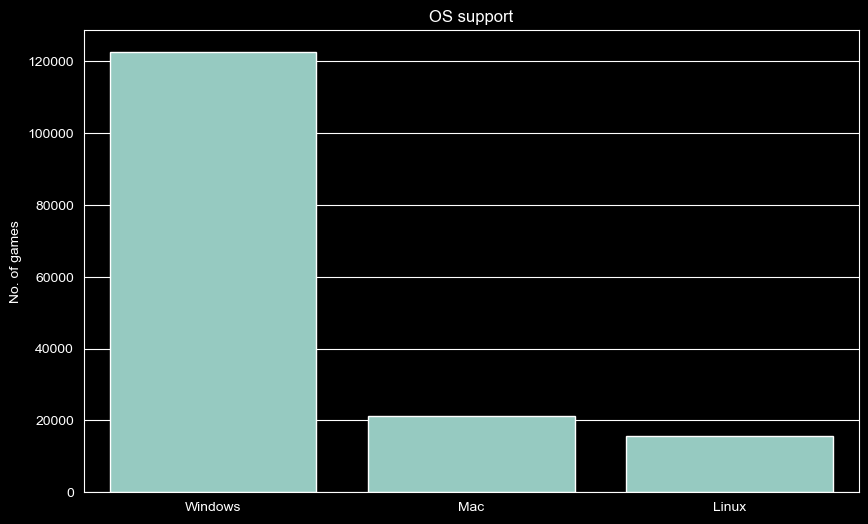

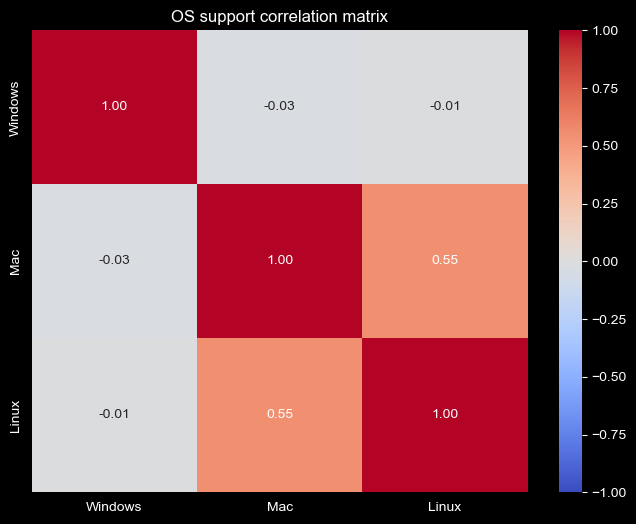

In [128]:
platforms = df[['Windows', 'Mac', 'Linux']].sum()
print(platforms)

plt.figure(figsize=(10, 6))
sns.barplot(x=platforms.index, y=platforms.values)
plt.title('OS support')
plt.xlabel('')
plt.ylabel('No. of games')
plt.show()

corr_matrix = df[['Windows', 'Mac', 'Linux']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('OS support correlation matrix')
plt.show()

It was quite predictable that Windows was going to dominate the field although it's worth mentioning that not ALL games are supported by it. We can see a slight correlation between games when it comes to being released on Mac and Linux.

Linux  False  True 
Mac                
False  96917   4401
True    9987  11305


<Axes: xlabel='Linux', ylabel='Mac'>

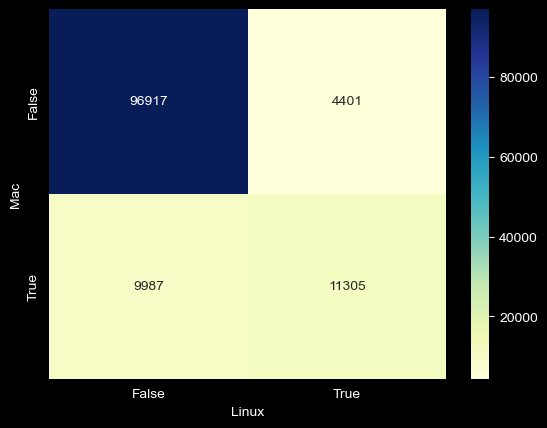

In [129]:
cross_tab = pd.crosstab(df['Mac'], df['Linux'])
print(cross_tab)

# Wizualizacja tabeli
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu")

We can also see that if a game was released for linux then it will likely also be released for mac, but not the other way around.

# 2) Exploring the relationship between price and metacritic scores
##### !A score of 0 is considered as NotGiven!
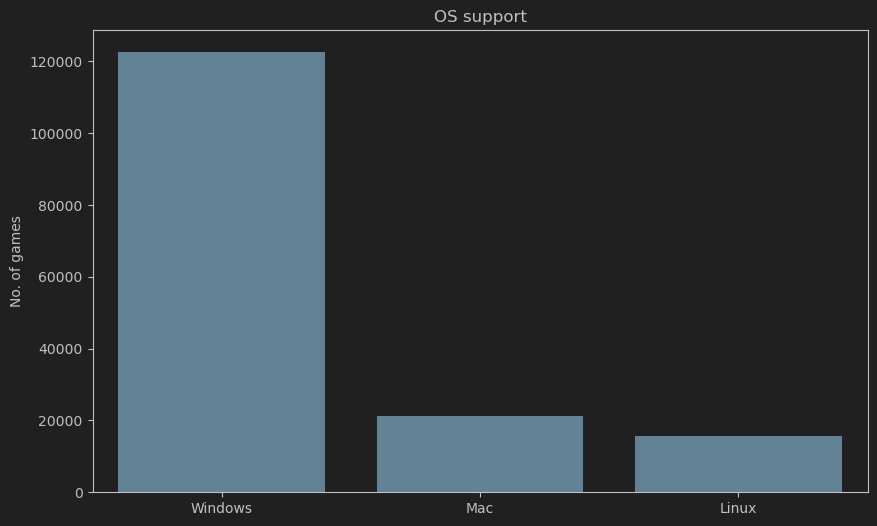

Let's begin by creating a dataframe filled with records which were given a score different from 0:

No. records:  4022


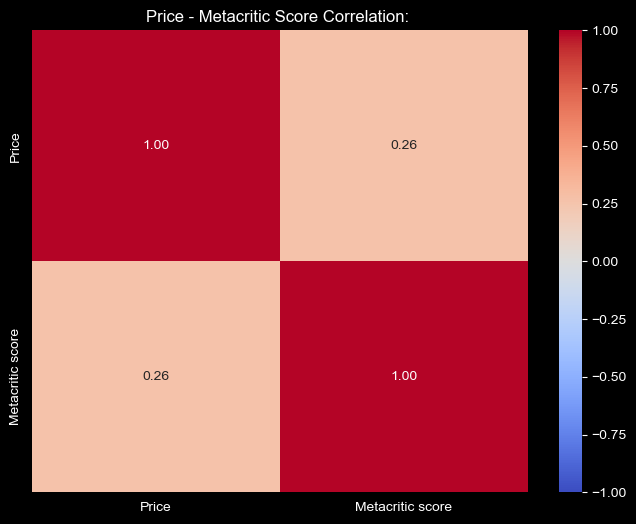

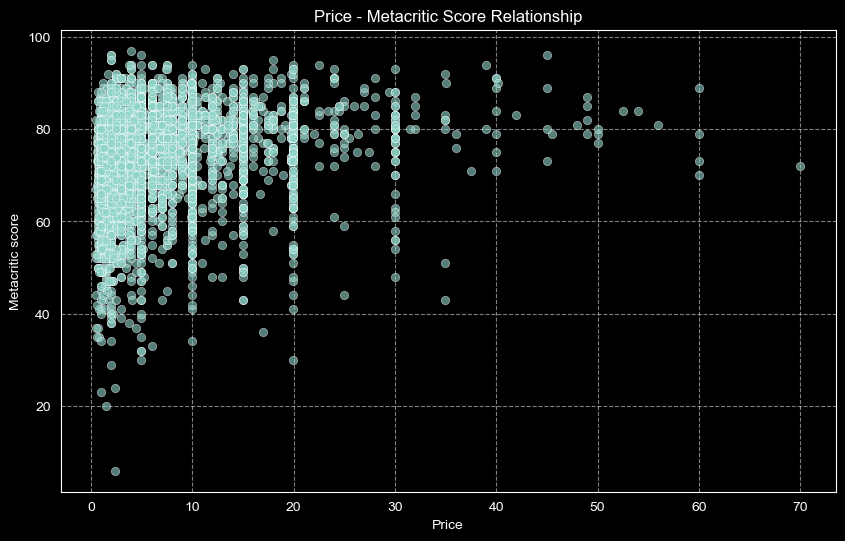

In [130]:
df_price_metacritic = df[(df['Price'] > 0) & (df['Metacritic score'] > 0)].copy()

print("No. records: ", len(df_price_metacritic))

corr_matrix = df_price_metacritic[['Price', 'Metacritic score']].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Price - Metacritic Score Correlation: ')


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_price_metacritic, x='Price', y='Metacritic score', alpha=0.6)
plt.title('Price - Metacritic Score Relationship')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Only a relatively small amount of records had a Meta score > 0 (4k out of 120k). One could say that it makes most of the games available on steam rather "niche". "Niche" enough to not grab gaming media's interest <br>
One could find this quite intuitive due to metacritic being known for reviewing games of mostly great popularity.
Our correlation matrix calculated for this sample shows signs that there is no meaningful correlation between these two.
<br> We can dive a bit deeper and check how price differs between games with __really high__ review scores (>80):

No. records:  1076


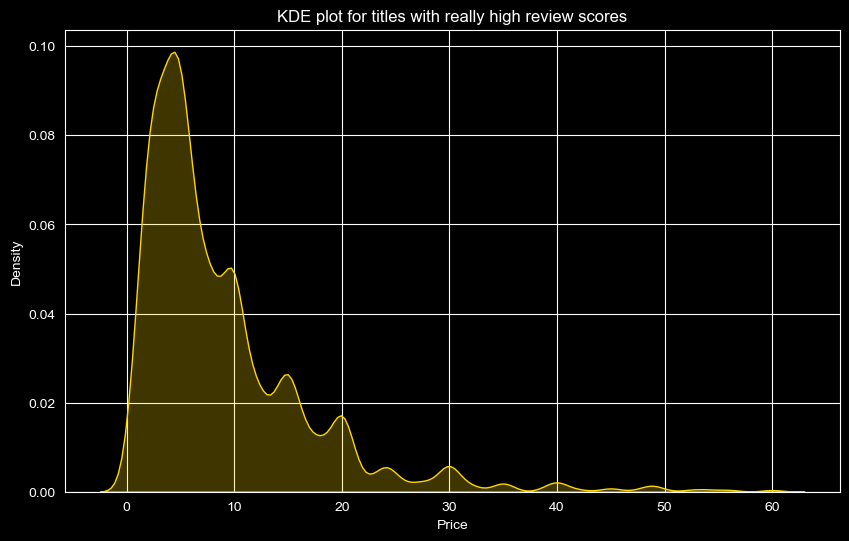

Mode:  0    4.99
Name: Price, dtype: float64
Median:  5.99


In [131]:
df_price_metacritic_high=df_price_metacritic[df_price_metacritic['Metacritic score']>80].copy()
print("No. records: ", len(df_price_metacritic_high))

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_price_metacritic_high, x='Price', fill=True, bw_adjust=0.5, color='gold')
plt.title('KDE plot for titles with really high review scores')
plt.show()
print("Mode: ", df_price_metacritic_high['Price'].mode())
print("Median: ", df_price_metacritic_high['Price'].median())

Based on available data we can say that the "average" very positively reviewed game costs up to 10 USD (Seems like indie games are winning critics' hearts over AAA games). <br>
It is worth mentioning that there is visible skewness to the right. <br>
What's also interesting is that we can see spikes at a few price points which might be connected to the fact that most devs publish games at popular prices we usually see on the main store page such as [USD] 4.99; 7.99; 9.99; 14.99; 17.99; 19.99 etc. I believe these prices correspond with results from many psychological studies about what buyers think (I believe it also connects with the prices we see in physical stores)

Now let's take a look from a different angle: Do expensive (>39USD - arbitrary cutoff) games tend to have higher scores?

No. Premium with high rating:  16
Premium with rating > 0:  30
Premium Overall:  885

No. Budget with high rating:  1060
Budget with rating > 0:  4226


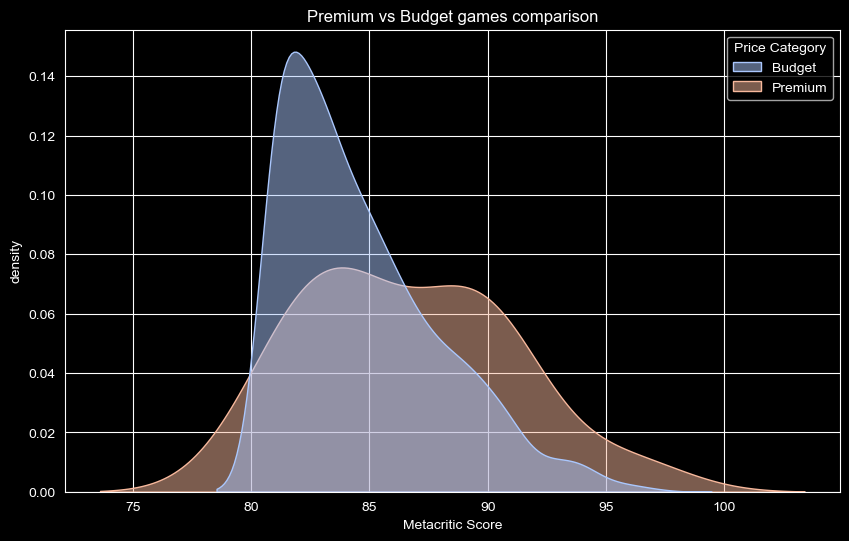

In [132]:
cutoff=39
df_price_metacritic_high['Price Category'] = df_price_metacritic_high['Price'].apply(
    lambda x: 'Premium' if x > cutoff else 'Budget'
)
print('No. Premium with high rating: ', len(df_price_metacritic_high[df_price_metacritic_high['Price Category'] == 'Premium']))
print('Premium with rating > 0: ', len(df[(df['Price'] > cutoff) & (df['Metacritic score'] > 0)]))
print('Premium Overall: ', len(df[df['Price'] > cutoff]), end='\n\n')
print('No. Budget with high rating: ', len(df_price_metacritic_high[df_price_metacritic_high['Price Category'] == 'Budget']))
print('Budget with rating > 0: ', len(df[(df['Price'] <= cutoff) & (df['Metacritic score'] > 0)]))

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_price_metacritic_high, x='Metacritic score', hue='Price Category',
            fill=True, common_norm=False, palette='coolwarm', alpha=0.5)

plt.title('Premium vs Budget games comparison')
plt.xlabel('Metacritic Score')
plt.ylabel('density')
plt.show()

It's important to note that these categories are very imbalanced in terms of size (16 Premium :: 1060 budget). It seems that only 16 out of 885 (whilst only 30 of 885 received any scores) premium games were rated as high which visibly distorts the kde plot and makes it prone to changes. One may conclude that Premium games have higher expectations due to their premium price compared to budget productions. <br>
One could draw a conclusion that a higher budget meaning a better (or one in general) marketing campaign does not directly result in the game receiving better scores.<br>
However, let's see how scores distribute for all premium games if we don't take into account only the highly scored titles.

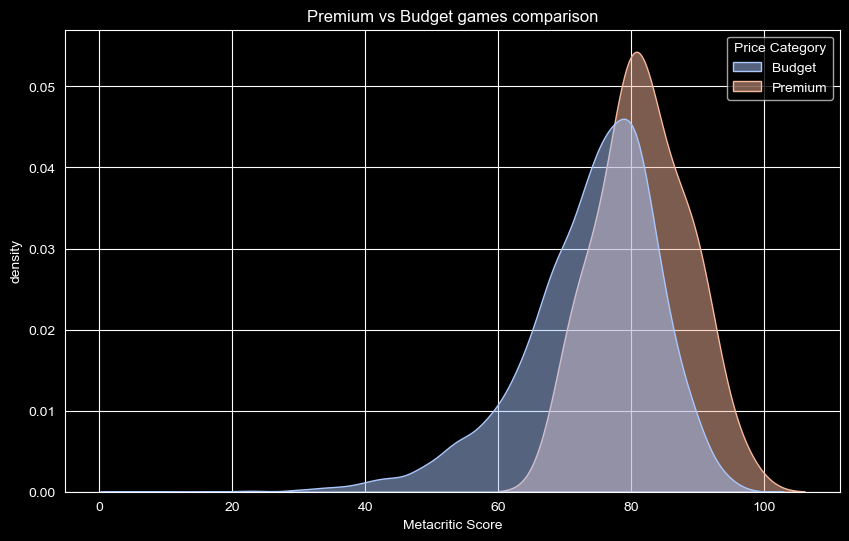

In [133]:
df_price_metacritic['Price Category'] = df_price_metacritic['Price'].apply(
    lambda x: 'Premium' if x > cutoff else 'Budget'
)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_price_metacritic, x='Metacritic score', hue='Price Category',
            fill=True, common_norm=False, palette='coolwarm', alpha=0.5)

plt.title('Premium vs Budget games comparison')
plt.xlabel('Metacritic Score')
plt.ylabel('density')
plt.show()

Now the "premium" price range kde plot for scores seems a bit smoother, although we are still working on a relatively small sample size. We can see the difference in variance between the two plots with visible skewness to the left in the budget category. <br>
To close off this chapter let's also look if scores can tell us something about the number of estimated owners. First we'll need to parse our current data in the estimated owners collumn from a string to a number. Let's check what the values look like.

In [134]:
print(df_price_metacritic['Estimated owners'].value_counts())

Estimated owners
200000 - 500000         761
0 - 20000               580
100000 - 200000         564
50000 - 100000          529
20000 - 50000           502
500000 - 1000000        420
1000000 - 2000000       329
2000000 - 5000000       225
5000000 - 10000000       61
10000000 - 20000000      23
0 - 0                    14
20000000 - 50000000      13
50000000 - 100000000      1
Name: count, dtype: int64


Now, let's add a column with values set to the mean of their corresponding interval:

In [135]:
split_data = df_price_metacritic['Estimated owners'].str.split(' - ', expand=True).astype(float)
df_price_metacritic['Owners midpoint'] = split_data.mean(axis=1)

Let's visualize the relationship between score and estimated owners as well as calculate correlation between the two:

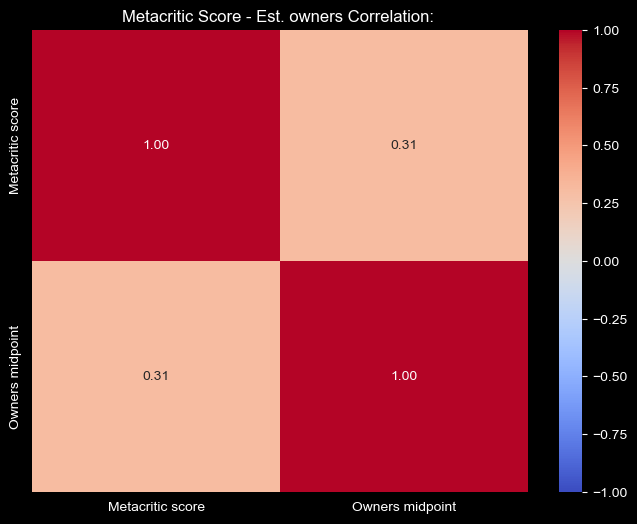

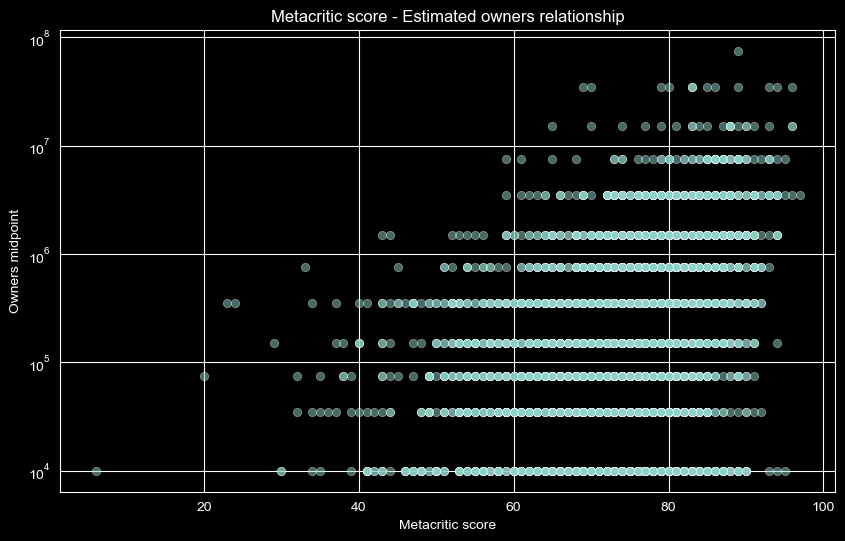

In [136]:
plt.figure(figsize=(8, 6))
corr_matrix = df_price_metacritic[['Metacritic score', 'Owners midpoint']].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Metacritic Score - Est. owners Correlation: ')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_price_metacritic, x='Metacritic score', y='Owners midpoint', alpha=0.5)
plt.yscale('log')
plt.title('Metacritic score - Estimated owners relationship')

plt.show()


We can see a subtle tendency for games with a lot of owners (midpoint above 1 mil) to fall onto the right side of the plot. It's important to note that a high score does **NOT** guarantee a lot of owners, but it seems that high scores could mean a higher probability for the game to acquire a lot of players.

### To summarize:
* Only a small percentage of games (around 3%) received a Metacritic score, suggesting that a large amount of games published on steam don't get the privilege of attracting gaming media's attention.
* Games with really high review scores mostly cost less than 10 USD which implies that indie games tend to win over their critics hearts (Maybe because of expensive games bringing more expectations?).
* Price Density estimation plot shows tendencies in game pricing (e.g 7.99 USD, 14.99 USD), which shows signs of devs applying sales psychology.
* Data lacks correlation between price and review scores: A higher prices does not directly result in higher scores ("Premium" group >39 USD).
* Metacritic scores vs Est. owners: Scores tend to play a role in allowing a game to reach a huge player count although they do not strictly guarantee the game being a unicorn. There are lots of games with a relatively small playerbase rated really generously.


# 3) Comparing the numbers of releases and average scores over the years

We need to remember about the fact that a score of 0 means no score at all not an actual score of 0. Thanks to how the mean in pandas automatically ignores NaN values we can simply replace our 0s with NaNs.

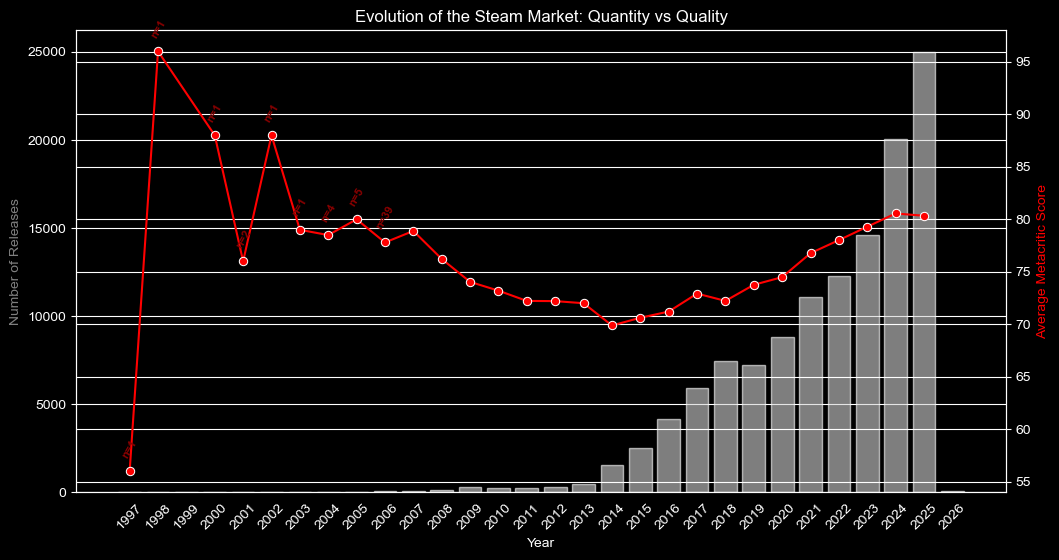

In [137]:
df_yearly_stats=df.copy()
df_yearly_stats['Year']=df_yearly_stats['Release date'].dt.year
df_yearly_stats['Metacritic score']=df_yearly_stats['Metacritic score'].replace(to_replace=0, value=np.nan)

df_yearly_stats = df_yearly_stats.groupby('Year').agg({
    'AppID': 'count',
    'Metacritic score': ['mean', 'count']
})

df_yearly_stats.columns = ['Game Count', 'Avg Score', 'Rated Count']

fig, ax1 = plt.subplots(figsize=(12,6))
plt.xticks(rotation=45)

sns.barplot(x=df_yearly_stats.index, y=df_yearly_stats['Game Count'], ax=ax1, color='lightgray', alpha=0.6)
ax1.set_ylabel('Number of Releases', color='gray')

ax2 = ax1.twinx()
sns.lineplot(x=range(len(df_yearly_stats)), y=df_yearly_stats['Avg Score'], ax=ax2, color='red', marker='o')
ax2.set_ylabel('Average Metacritic Score', color='red')

#annotating means with small sample sizes
for i, (year, row) in enumerate(df_yearly_stats.iterrows()):
    n_rated = int(row['Rated Count'])
    if n_rated <= 50:
        ax2.text(i, row['Avg Score'] + 1.1, f"n={n_rated}",
                 color='darkred', ha='center', va='bottom',
                 fontsize=8, rotation=60, fontweight='bold')


plt.title('Evolution of the Steam Market: Quantity vs Quality')


plt.show()



We can see an exponential-like growth in the number of releases after 2014 - possibly due to steam introducing greenlight (which was later replaced with steam direct around 2018). It was a mechanism/platform for devs to showcase their games so the community could vote whether the game should come to steam.

It is very important to note that games released before 2003 were added to steam only after the platform was created. I've also added annotations for Metacritic Score means calculated for less than 50 titles (To emphasize the stability of the scores or rather lack of it)
1998 is also a quite important year because that's when valve released half-life. It was the game that changed everything for them and brought the capital necessary to create more games and ultimately - steam.

The plot also tells us that not only did the amount of games receiving scores increase but also their mean scores have been increasing since 2014. This might connect with the release of greenlight - although it was flawed I believe it had somewhat of a contribution. Games receiving community votes before coming to steam would technically get their first form of quality control before receiving actual critic reviews.

# 4) Studying correlation between estimated owners and average playtime

What I want to try to find out is whether popular games were bought purely because of hype or if they are actually great games with great retention and high playtimes.

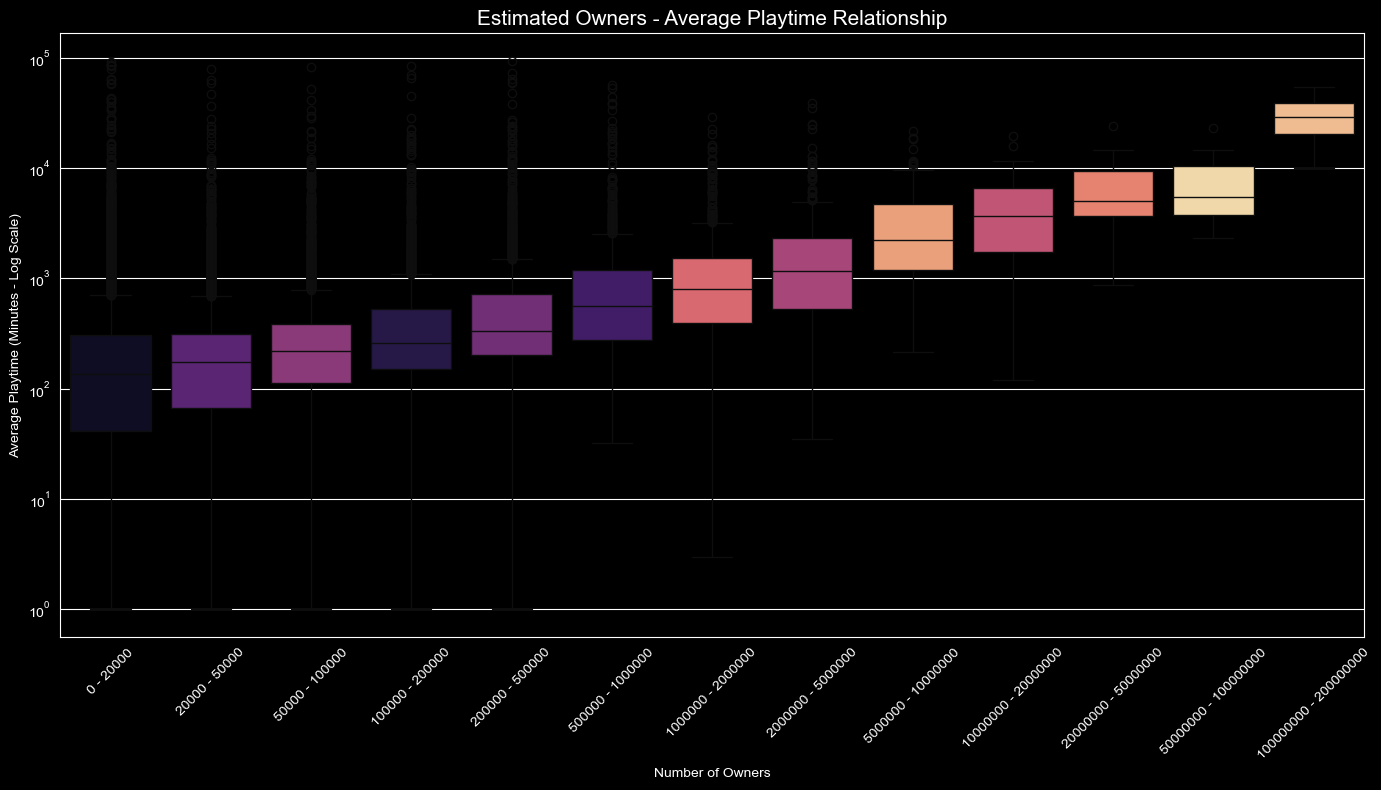

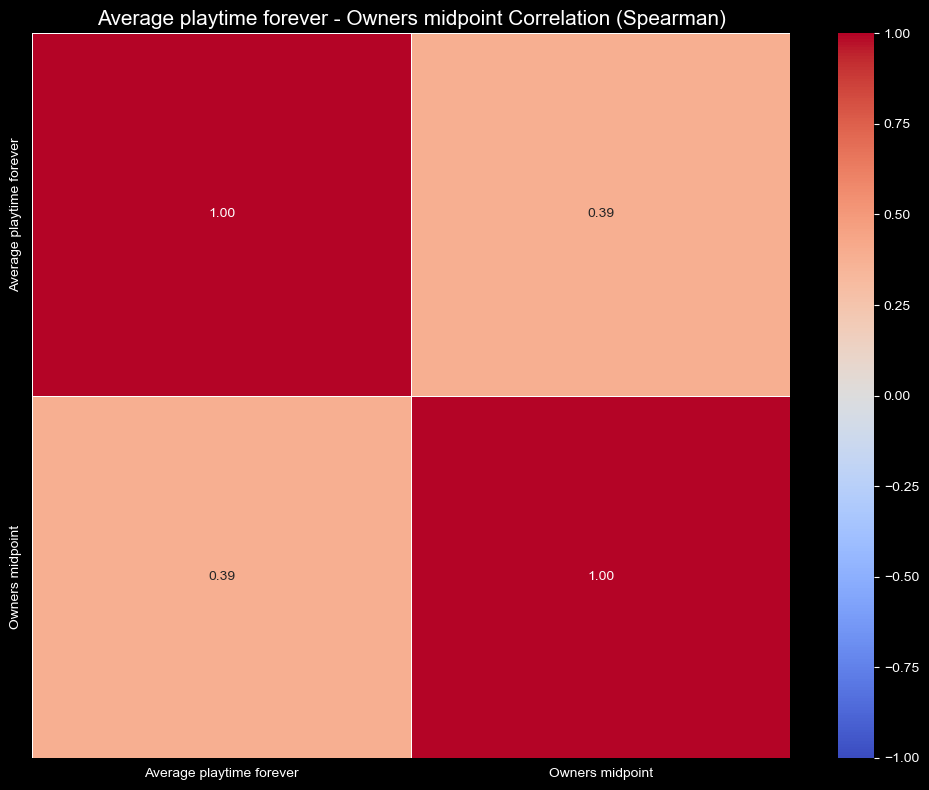

                      Name       Estimated owners  Average playtime forever
4193                Dota 2  100000000 - 200000000                     54064
45509     Counter-Strike 2  100000000 - 200000000                     33906
8878   PUBG: BATTLEGROUNDS  100000000 - 200000000                     23787
54502        Apex Legends™  100000000 - 200000000                     10073
                             Name      Estimated owners  \
57377             Team Fortress 2  50000000 - 100000000   
59122   Grand Theft Auto V Legacy  50000000 - 100000000   
105321        New World: Aeternum  50000000 - 100000000   
85553                    Unturned  50000000 - 100000000   
27431               Call of Duty®  50000000 - 100000000   

        Average playtime forever  
57377                      23093  
59122                      14657  
105321                     10500  
85553                       8683  
27431                       5485  
                    Name Estimated owners  Average play

In [138]:
df_playtime = df[(df['Average playtime forever'] > 0) &
                   (df['Average playtime forever'] < 100000)].copy()

split_data = df_playtime['Estimated owners'].str.split(' - ', expand=True).astype(float)
df_playtime['Owners midpoint'] = split_data.mean(axis=1)

owner_order = sorted(df_playtime['Estimated owners'].unique(),
                     key=lambda x: int(x.split(' - ')[0].strip()))

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_playtime, x='Estimated owners', y='Average playtime forever',
            order=owner_order, palette='magma', hue='Estimated owners')

plt.yscale('log')
plt.xticks(rotation=45)

plt.title('Estimated Owners - Average Playtime Relationship', fontsize=15)
plt.xlabel('Number of Owners')
plt.ylabel('Average Playtime (Minutes - Log Scale)')

plt.tight_layout()

correlation_matrix = df_playtime[['Average playtime forever', 'Owners midpoint']].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Average playtime forever - Owners midpoint Correlation (Spearman)', fontsize=15)
plt.tight_layout()
plt.show()



cols = ['Name', 'Estimated owners', 'Average playtime forever']

print(df_playtime[df_playtime['Estimated owners'] == '100000000 - 200000000']
      .sort_values(by='Average playtime forever', ascending=False)[cols]
      .head())

print(df_playtime[df_playtime['Estimated owners'] == '50000000 - 100000000']
      .sort_values(by='Average playtime forever', ascending=False)[cols]
      .head())

print(df_playtime[df_playtime['Estimated owners'] == '0 - 20000']
      .sort_values(by='Average playtime forever', ascending=False)[cols]
      .head())

First of all we can see a lot of outliers in the niche categories. It's important to note that the further we head to the right the smaller our samples get - the right-most category consists of only 4 games (Well known gems like Dota 2 or Counter-Strike 2).
Although we can notice significant differences in variances between categories we can see a bullish trend in group median values. What's also interesting is the fact that games with a tiny playerbase (sub 20k) are still able to achieve high playtime. I believe this could be due to the games being idle simulators (which require a lot of playtime to complete) - e.g. Idle Superpowers, games which could attract specific audiences that would spend a lot of time in them - e.g. low-quality meme-titles with artificial engagement (no. 4 spot) or just simulators like Sim Empire. Let's quickly check examples of games with a really low playtime:

In [139]:
print(df_playtime[df_playtime['Estimated owners'] == '0 - 20000']
      .sort_values(by='Average playtime forever', ascending=True)[cols]
      .head())

print(df_playtime[df_playtime['Estimated owners'] == '20000 - 50000']
      .sort_values(by='Average playtime forever', ascending=True)[cols]
      .head())

                      Name Estimated owners  Average playtime forever
63053   Depraved Awakening        0 - 20000                         1
101052        Star General        0 - 20000                         1
55044            ArcBall 2        0 - 20000                         1
37678       Casual Penalty        0 - 20000                         1
59530      Cargo Simulator        0 - 20000                         1
                                         Name Estimated owners  \
16411                            Gaia Project    20000 - 50000   
45675                       I Am Overburdened    20000 - 50000   
108120  Trapper Knight, Sharpshooter Princess    20000 - 50000   
116374                           Mystery Loss    20000 - 50000   
108587      Trivia Vault: Classic Rock Trivia    20000 - 50000   

        Average playtime forever  
16411                          1  
45675                          1  
108120                         1  
116374                         1  
108587  

There are lots of games which have a depressingly low playtime none of which I've ever heard about. I figure this might be due to these games being given to players via random keys from 3rd party marketplaces (which I know from experience). Another reason could be that players receive such games as part of a larger bundle, never launching them in the first place. The main reason and also the most obvious one is that many of these games are low-quality cash-grabs players don't even bother to try out.

# 5) Achievements vs Playtime (Engagement Analysis) - do achievements make players want to play more?


Personally I'm an achievement hunter so I'm not sure whether that's a good or a bad thing. What I want to find out is whether completionism is a niche thing or do most players spend more time playing games which showcase their progress in the form of achievements.

Let's start by filtering out games which have 0 or more than 200 achievements (because these would likely be achievement spams for people wanting to decorate their steam profiles. I am aware of games such as payday2 with unrealistically high amounts of achievements (1200+)). Filtering out games with avg playtime forever > 250h (because even though some games could be played for a really long time, if they are not idlers they're unlikely to have such high **average** playtime's). Games with avg playtimes under 1h could also appear as not important. I based my estimates on the time it took me to max out witcher 3 + dlcs, unbelievably it took me 187.5h compared to 187h estimate by PStrophies.

In [140]:
df_ach = df[(df['Achievements'] <= 200) & (df['Achievements']>0) &
            (df['Average playtime forever'] < 15000) & (df['Average playtime forever'] >= 60)].copy()


Calculating correlation:

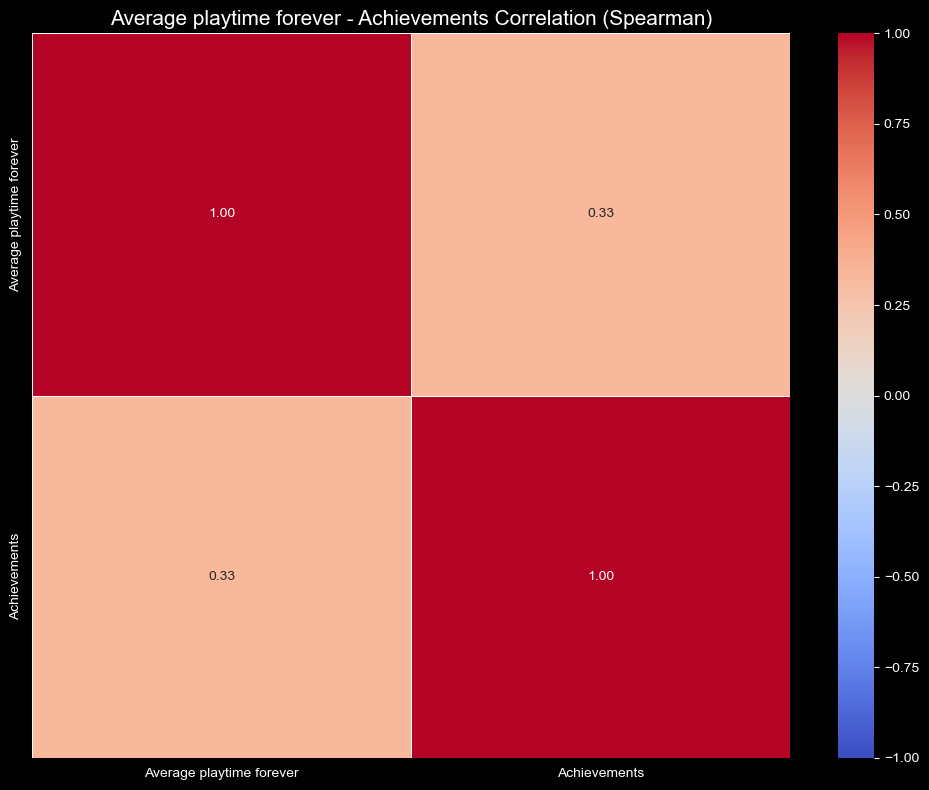

In [141]:
correlation_matrix = df_ach[['Average playtime forever', 'Achievements']].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Average playtime forever - Achievements Correlation (Spearman)', fontsize=15)
plt.tight_layout()
plt.show()

Let's visualize our data:

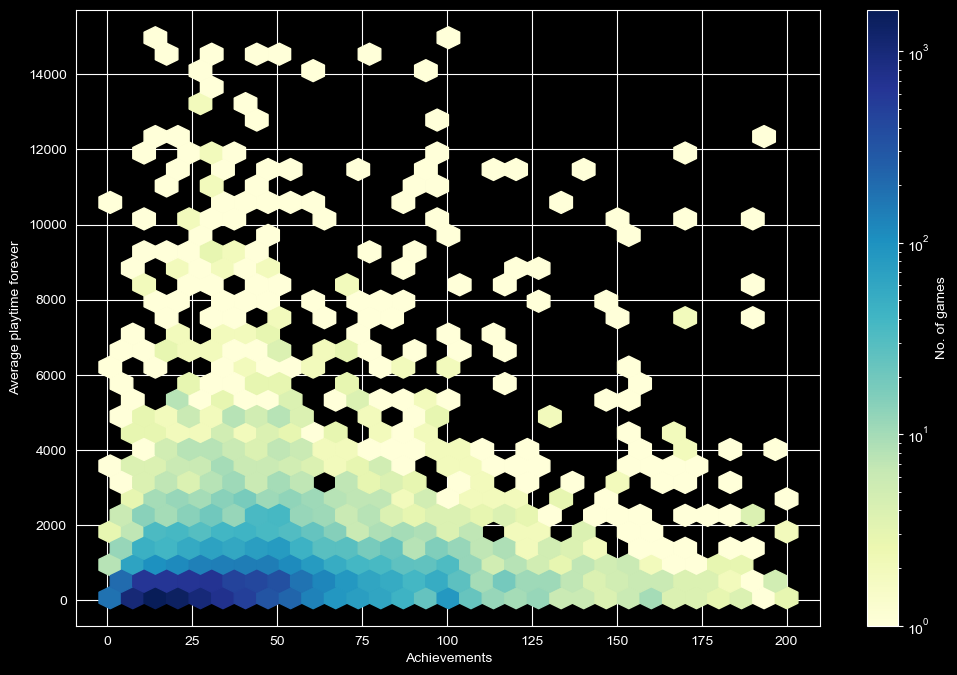

In [142]:
import matplotlib.colors as colors

plt.figure(figsize=(12, 8))
plt.hexbin(df_ach['Achievements'],
           df_ach['Average playtime forever'],
           gridsize=30, cmap='YlGnBu', mincnt=1, norm=colors.LogNorm())

cb = plt.colorbar(label='No. of games')
plt.title('', fontsize=15)
plt.xlabel('Achievements')
plt.ylabel('Average playtime forever')
plt.show()

As you can see most of the data sits under 4000mins of playtime and under 125 achievements. There is also a lot of empty space between hexagons depicting games with a lot of achievements - seems reasonable because getting 150+ achievements usually takes much longer for the average player. Games with a lot of achievements tend to take longer to master, but unfortunately it seems that most players don't bother playing them to get absolutely everything they have to offer.

# Summary


We've found that adding achievements does not guarantee more engagement from players, however if they decide to play the game longer it's natural for it to require more time to complete. <br>
None of our experiments showed definitive correlation between features - the highest value we've found was 0.55 (chapter 1 - Linux - Mac). <br> Most analyses required filtering the data because of how many junk games steam allows to pass through. <br>
We've also found that average Metacritic review scores have been increasing over the years. <br>
Speaking of reviews, better ones do not directly mean the game selling well but they seem to be a necessary criterion for it to have a chance at doing so. <br>
Lastly we've seen that games released for mac are more likely to be released on linux than games for linux being released on mac.

I may have went a bit overboard with chapter 2 but I was in flowstate while creating it. <br>
Thank you for listening to my TED talk